In [2]:
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [3]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print("Total samples:", len(df_all))


Total samples: 7227


In [4]:
    keep_emotions = ["angry", "happy", "sad"]
df_all = df_all[df_all["emotion"].isin(keep_emotions)]

print(df_all["emotion"].value_counts())


emotion
happy    1463
sad      1463
angry    1463
Name: count, dtype: int64


In [5]:
SAMPLE_RATE = 22050
DURATION = 4
N_MELS = 128
MAX_LEN = 173

def extract_logmel(path):
    y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=DURATION)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS,
        n_fft=1024, hop_length=512
    )

    logmel = librosa.power_to_db(mel)
    logmel = (logmel - logmel.mean()) / (logmel.std() + 1e-6)

    if logmel.shape[1] < MAX_LEN:
        logmel = np.pad(logmel, ((0,0),(0,MAX_LEN-logmel.shape[1])))
    else:
        logmel = logmel[:, :MAX_LEN]

    return logmel.T  # (time, mel)


In [6]:
X = np.array([extract_logmel(p) for p in df_all["path"]])


c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
le = LabelEncoder()
y = le.fit_transform(df_all["emotion"])

print("Classes:", le.classes_)


Classes: ['angry' 'happy' 'sad']


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)


(3072, 173, 128) (658, 173, 128) (659, 173, 128)


In [9]:
model = tf.keras.Sequential([
    layers.Conv1D(64, 5, activation="relu", input_shape=(173,128)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 5, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Bidirectional(layers.LSTM(128)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax")
])


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 169, 64)           41024     
                                                                 
 batch_normalization (Batch  (None, 169, 64)           256       
 Normalization)                                                  
                                                                 
 max_pooling1d (MaxPooling1  (None, 84, 64)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 80, 128)           41088     
                                                                 
 batch_normalization_1 (Bat  (None, 80, 128)           512       
 chNormalization)                                                
                                                        

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32
)


Epoch 1/30
96/96 [==============================] - 9s 65ms/step - loss: 0.7796 - accuracy: 0.6419 - val_loss: 0.7309 - val_accuracy: 0.6246
Epoch 2/30
96/96 [==============================] - 5s 54ms/step - loss: 0.6513 - accuracy: 0.7223 - val_loss: 0.6316 - val_accuracy: 0.7264
Epoch 3/30
96/96 [==============================] - 5s 52ms/step - loss: 0.5830 - accuracy: 0.7611 - val_loss: 0.7178 - val_accuracy: 0.7067
Epoch 4/30
96/96 [==============================] - 5s 53ms/step - loss: 0.5375 - accuracy: 0.7783 - val_loss: 0.6043 - val_accuracy: 0.7173
Epoch 5/30
96/96 [==============================] - 5s 54ms/step - loss: 0.4909 - accuracy: 0.7946 - val_loss: 0.7942 - val_accuracy: 0.6550
Epoch 6/30
96/96 [==============================] - 5s 53ms/step - loss: 0.4371 - accuracy: 0.8288 - val_loss: 0.7200 - val_accuracy: 0.6793
Epoch 7/30
96/96 [==============================] - 5s 55ms/step - loss: 0.3995 - accuracy: 0.8480 - val_loss: 0.6198 - val_accuracy: 0.7508
Epoch 8/30
96

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("3-Emotion CRNN Test Accuracy:", test_acc)


21/21 [==============================] - 0s 16ms/step - loss: 1.3381 - accuracy: 0.7572
3-Emotion CRNN Test Accuracy: 0.7572078704833984


In [14]:
EPOCHS = 30
BATCH_SIZE = 32

In [15]:

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/30
96/96 [==============================] - 6s 65ms/step - loss: 0.0959 - accuracy: 0.9697 - val_loss: 1.1389 - val_accuracy: 0.7599
Epoch 2/30
96/96 [==============================] - 6s 64ms/step - loss: 0.0653 - accuracy: 0.9749 - val_loss: 1.1251 - val_accuracy: 0.7508
Epoch 3/30
96/96 [==============================] - 6s 67ms/step - loss: 0.0488 - accuracy: 0.9844 - val_loss: 1.0202 - val_accuracy: 0.7751
Epoch 4/30
96/96 [==============================] - 6s 66ms/step - loss: 0.0184 - accuracy: 0.9948 - val_loss: 1.2975 - val_accuracy: 0.7477
Epoch 5/30
96/96 [==============================] - 6s 61ms/step - loss: 0.0512 - accuracy: 0.9788 - val_loss: 1.4370 - val_accuracy: 0.7644
Epoch 6/30
96/96 [==============================] - 6s 62ms/step - loss: 0.0600 - accuracy: 0.9801 - val_loss: 1.0900 - val_accuracy: 0.7690
Epoch 7/30
96/96 [==============================] - 6s 63ms/step - loss: 0.0413 - accuracy: 0.9837 - val_loss: 1.5686 - val_accuracy: 0.7371
Epoch 8/30
96

In [17]:
import matplotlib.pyplot as plt

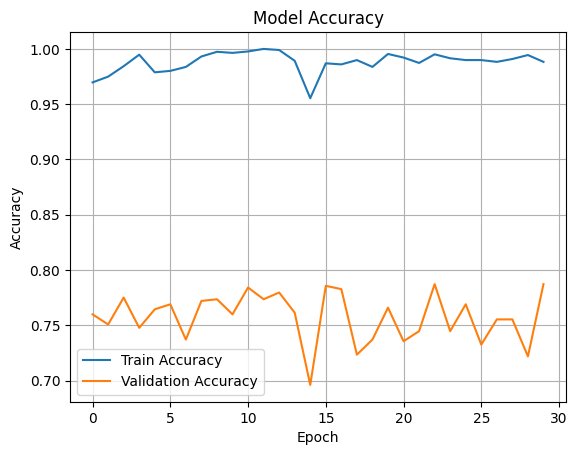

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.show()

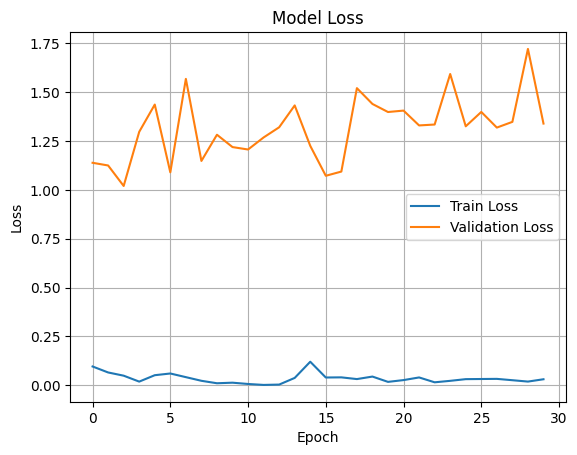

In [19]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])
plt.grid(True)

plt.show()

In [20]:
# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.savefig("accuracy_graph.png")
plt.close()

# Loss graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.savefig("loss_graph.png")
plt.close()

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test, y_pred, target_names=le.classes_
))
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test, y_pred, target_names=le.classes_
))


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
              precision    recall  f1-score   support

       angry       0.83      0.68      0.75       219
       happy       0.66      0.76      0.70       220
         sad       0.82      0.84      0.83       220

    accuracy                           0.76       659
   macro avg       0.77      0.76      0.76       659
weighted avg       0.77      0.76      0.76       659

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

       angry       0.83      0.68      0.75       219
       happy       0.66      0.76      0.70       220
         sad       0.82      0.84      0.83       220

    accuracy                           0.76       659
   macro avg       0.77      0.76      0.76       659
weighted avg       0.77      0.76      0.76       659



In [ ]:
import os

# Create models folder if it doesn't exist
save_dir = r"D:\SER_Cross\models"
os.makedirs(save_dir, exist_ok=True)

# Save the trained model
model.save(os.path.join(save_dir, "crnn_3emotion_final.h5"))

print("✅ 3-Emotion CRNN model saved successfully")


✅ 3-Emotion CRNN model saved successfully
